<a href="https://colab.research.google.com/github/Arif118/Leukemia-Classification-from-Gene-Expression-/blob/main/Leukemia_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

#Dataset Overview

This project uses a leukemia gene expression dataset containing thousands of gene informatiion collected from leukemia patients. The dataset includes two major leukemia classes: Acute Lymphoblastic Leukemia (ALL) and Acute Myeloid Leukemia (AML). Since gene expression datasets are highly dimensional, preprocessing and dimensionality reduction techniques should be applied before training machine learning models.

In [139]:
df = pd.read_csv('/content/leukemia_big.csv')
df.head(5)

,ALL,ALL.1,ALL.2,ALL.3,ALL.4,ALL.5,ALL.6,ALL.7,ALL.8,ALL.9,...,AML.15,AML.16,AML.17,AML.18,AML.19,AML.20,AML.21,AML.22,AML.23,AML.24
0,-1.533622,-0.867610,-0.433172,-1.671903,-1.187689,-1.127234,-1.045409,-0.106917,-1.198796,-1.190899,...,-0.436650,-1.274708,-0.681458,-0.876610,-0.624022,-0.431628,-1.435259,-0.671954,-1.013161,-0.969482
1,-1.235673,-1.275501,-1.184492,-1.596424,-1.335256,-1.113730,-0.800880,-0.745177,-0.849312,-1.190899,...,-0.915483,-1.354363,-0.653559,-1.096250,-1.066594,-1.335256,-1.204586,-0.751457,-0.889592,-1.080988
2,-0.333983,0.375927,-0.459196,-1.422571,-0.797493,-1.362768,-0.671954,-1.175674,0.320813,0.646610,...,-0.736156,-0.022153,-0.037455,-0.567335,-1.100749,-0.552938,-0.948874,-0.231657,-0.742163,-0.779500
3,0.488702,0.444011,0.436264,0.193353,0.235632,-0.360312,0.184941,0.425653,0.333983,0.235270,...,0.083781,0.356562,0.416241,0.533986,0.227505,0.416816,0.408202,0.326556,0.361813,0.298864
4,-1.300893,-1.229660,-1.325882,-1.818329,-1.311206,-1.513975,-1.651624,-1.339555,-0.593132,0.133302,...,-1.547444,-1.264475,-1.512318,-1.469583,-1.283472,-0.977672,-1.090178,-1.545120,-1.174272,-1.443183


In [140]:
df.shape

(7128, 72)

In [141]:
df = df.T
df.index = df.index.map(str) # converts index elements to string
df["Target"] = df.index.map(lambda x: x.split('.')[0])
df.reset_index(drop=True, inplace=True)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,7119,7120,7121,7122,7123,7124,7125,7126,7127,Target
0,-1.533622,-1.235673,-0.333983,0.488702,-1.300893,-1.682668,-2.010995,-1.449186,0.035344,-1.088905,...,1.268788,-0.217954,0.255381,-1.057940,1.295992,0.733853,-0.301622,0.133657,-0.825596,ALL
1,-0.867610,-1.275501,0.375927,0.444011,-1.229660,-1.642072,0.572919,-1.588304,0.219574,0.119834,...,0.822880,-1.369024,0.542521,-0.796527,-0.218494,0.378380,-0.663166,-0.663166,-0.611045,ALL
2,-0.433172,-1.184492,-0.459196,0.436264,-1.325882,-1.407264,-0.264655,-1.147713,-0.573541,0.784512,...,0.642714,-0.466828,0.856140,-0.416816,1.132893,0.475669,-0.530138,1.566946,-0.805978,ALL
3,-1.671903,-1.596424,-1.422571,0.193353,-1.818329,-1.744469,-1.793197,-1.446178,-0.325815,-1.324191,...,0.462715,-0.585185,-0.181008,-0.611257,1.113077,0.148928,-0.625945,0.871972,-1.037246,ALL
4,-1.187689,-1.335256,-0.797493,0.235632,-1.311206,-1.654381,-1.441690,-1.058556,-0.582683,0.001758,...,0.750758,-0.380081,0.526298,-0.888026,0.719203,0.419502,-0.487514,0.358999,-0.742858,ALL


In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Columns: 7129 entries, 0 to Target
dtypes: float64(7128), object(1)
memory usage: 3.9+ MB


In [143]:
df.isna().sum()

,0
0,0
1,0
2,0
3,0
4,0
...,...
7124,0
7125,0
7126,0
7127,0


In [144]:
df.duplicated().sum()

np.int64(0)

In [145]:
target = df.pop('Target')
df.insert(0, 'Target', target)
df.head()

,Target,0,1,2,3,4,5,6,7,8,...,7118,7119,7120,7121,7122,7123,7124,7125,7126,7127
0,ALL,-1.533622,-1.235673,-0.333983,0.488702,-1.300893,-1.682668,-2.010995,-1.449186,0.035344,...,0.385567,1.268788,-0.217954,0.255381,-1.057940,1.295992,0.733853,-0.301622,0.133657,-0.825596
1,ALL,-0.867610,-1.275501,0.375927,0.444011,-1.229660,-1.642072,0.572919,-1.588304,0.219574,...,-0.158356,0.822880,-1.369024,0.542521,-0.796527,-0.218494,0.378380,-0.663166,-0.663166,-0.611045
2,ALL,-0.433172,-1.184492,-0.459196,0.436264,-1.325882,-1.407264,-0.264655,-1.147713,-0.573541,...,0.662728,0.642714,-0.466828,0.856140,-0.416816,1.132893,0.475669,-0.530138,1.566946,-0.805978
3,ALL,-1.671903,-1.596424,-1.422571,0.193353,-1.818329,-1.744469,-1.793197,-1.446178,-0.325815,...,0.161918,0.462715,-0.585185,-0.181008,-0.611257,1.113077,0.148928,-0.625945,0.871972,-1.037246
4,ALL,-1.187689,-1.335256,-0.797493,0.235632,-1.311206,-1.654381,-1.441690,-1.058556,-0.582683,...,0.176721,0.750758,-0.380081,0.526298,-0.888026,0.719203,0.419502,-0.487514,0.358999,-0.742858


In [146]:
print("\nClass Distribution:")
print(df["Target"].value_counts())


Class Distribution:
Target
ALL    47
AML    25
Name: count, dtype: int64


In [147]:
X = df.drop('Target', axis=1)
y = df['Target']

#2D Visualization
PCA was used to reduce the high-dimensional gene expression dataset into two principal components for visualization. A 2D scatter plot was then created using Seaborn to observe the separation between leukemia classes (ALL and AML). This visualization helps identify clustering patterns and class separability in the dataset.


In [148]:
plt.style.use("dark_background")

sns.set_style("darkgrid")
sns.set_palette("magma")

In [149]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [150]:
X_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
X_pca.head()

,PC1,PC2
0,1.831334,-14.073217
1,-5.152123,-12.964358
2,5.498994,7.050634
3,11.319360,6.304886
4,16.929608,2.181211


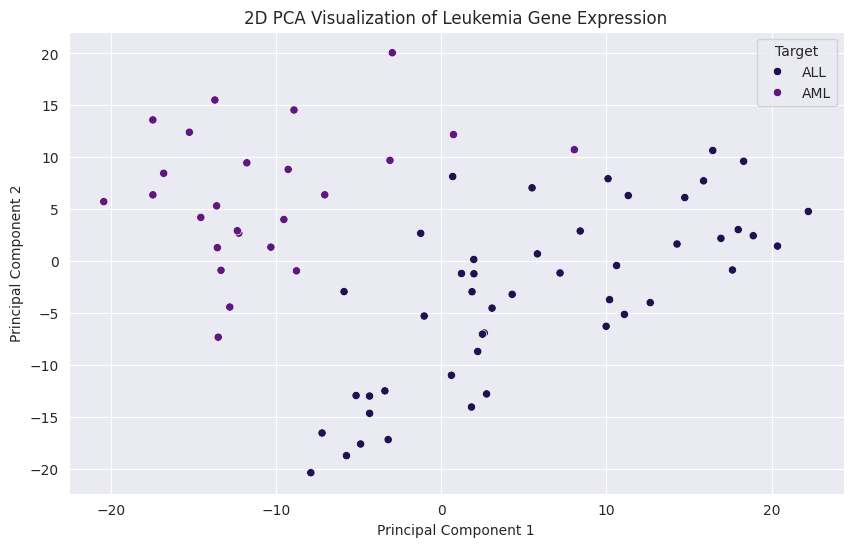

In [151]:
sns.scatterplot(data=X_pca, x='PC1', y='PC2', hue=y)
plt.title("2D PCA Visualization of Leukemia Gene Expression")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [152]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#PCA
Principal Component Analysis (PCA) is used to reduce the dimensionality of the dataset. Gene expression datasets often contain thousands of correlated or irrelevant genes, which can increase noise and computational complexity.

In [153]:
print("\n==============================")
print("Logistic Regression WITH PCA")
print("==============================")


Logistic Regression WITH PCA


In [175]:
start1 = time.time()

In [179]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.85)),
    ('model', LogisticRegression(max_iter=5000))
])

In [180]:
pipe.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=0.85)),
                ('model', LogisticRegression(max_iter=5000))])

In [157]:
y_pred_pca = pipe.predict(X_test)

In [158]:
train_accuracy = pipe.score(X_train, y_train)
test_accuracy = pipe.score(X_test, y_test)

print(f"\nTrain Accuracy : {train_accuracy}")
print(f"Test Accuracy  : {test_accuracy}")


Train Accuracy : 1.0
Test Accuracy  : 1.0


In [159]:

print("\nClassification Report:\n")

print(classification_report(y_test,y_pred_pca))


Classification Report:

              precision    recall  f1-score   support

         ALL       1.00      1.00      1.00        10
         AML       1.00      1.00      1.00         5

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



In [160]:
scores_with_pca = cross_val_score(pipe, X, y, cv=5)
print("Cross Validation Scores:")
print(scores_with_pca)

print(f"\nMean CV Accuracy : {scores_with_pca.mean():.4f}")

Cross Validation Scores:
[1.         1.         0.92857143 1.         1.        ]

Mean CV Accuracy : 0.9857


In [161]:
end1 = time.time()
print(f"\nExecution Time : {end1 - start1:.2f} seconds")


Execution Time : 1.85 seconds


In [162]:
print("\n==============================")
print("Logistic Regression WITHOUT PCA")
print("==============================")


Logistic Regression WITHOUT PCA


In [163]:
start2  = time.time()

pipe_without_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000))
])


In [164]:
pipe_without_pca.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=5000))])

In [165]:
y_pred_without_pca = pipe_without_pca.predict(X_test)

In [166]:
train_accuracy = pipe_without_pca.score(X_train, y_train)
test_accuracy = pipe_without_pca.score(X_test, y_test)

print(f"\nTrain Accuracy : {train_accuracy:.4f}")
print(f"Test Accuracy  : {test_accuracy:.4f}")


Train Accuracy : 1.0000
Test Accuracy  : 1.0000


In [167]:
print("\nClassification Report:\n")
print(classification_report(y_test,y_pred_without_pca))


Classification Report:

              precision    recall  f1-score   support

         ALL       1.00      1.00      1.00        10
         AML       1.00      1.00      1.00         5

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



In [168]:
scores_without_pca = cross_val_score(pipe_without_pca, X, y, cv=5)
print("Cross Validation Scores:")
print(scores_without_pca)
print(f"\nMean CV Accuracy : {scores_without_pca.mean():.4f}")

Cross Validation Scores:
[1.         1.         0.92857143 1.         1.        ]

Mean CV Accuracy : 0.9857


In [169]:
end2 = time.time()
print(f"\nExecution Time : {end2 - start2:.2f} seconds")


Execution Time : 2.08 seconds


In [170]:
print("\n==============================")
print("Final Comparison")
print("==============================")

print(f"\nWITH PCA Mean Accuracy    : {scores_with_pca.mean():.4f}")
print(f"WITHOUT PCA Mean Accuracy : {scores_without_pca.mean():.4f}")

print(f"\nWITH PCA Time    : {end1 - start1:.3f} sec")
print(f"WITHOUT PCA Time : {end2 - start2:.3f} sec")


Final Comparison

WITH PCA Mean Accuracy    : 0.9857
WITHOUT PCA Mean Accuracy : 0.9857

WITH PCA Time    : 1.850 sec
WITHOUT PCA Time : 2.080 sec


#Conclusion

This project demonstrates that machine learning models can effectively classify leukemia types using gene expression data. Dimensionality reduction with PCA significantly compressed the feature space while preserving predictive performance. The results highlight the potential of combining bioinformatics and machine learning techniques for analyzing high-dimensional biological datasets.